<a href="https://colab.research.google.com/github/akhunzakp/PCVK-2025/blob/main/Week10_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# Tugas 1: Menghubungkan Google Drive dan menyiapkan file
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Tugas 2: Import beberapa library yang dibutuhkan
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.morphology import skeletonize
from skimage import filters, io, color, morphology

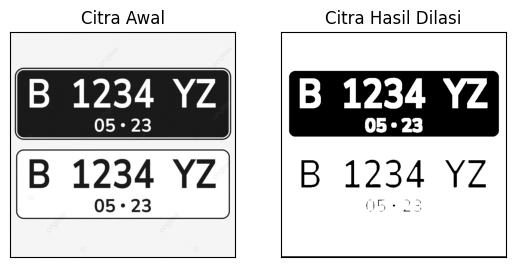

In [3]:
# Tugas 3: Dilasi tanpa library, dimodifikasi untuk SE Cross 3x3
def dilasi_citra(F, w):
    # Ukuran citra
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Struktur elemen dilasi (SED)
    SED = np.ones((w, w), dtype=np.uint8)
    constant1 = (w - 1) // 2

    # Proses Dilasi
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1,
                     j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD

# Baca citra grayscale
img_d = cv2.imread('/content/drive/MyDrive/Yuma Akhunza Kausar Putra/Plat Nomor.jpeg', 0)

# Threshold biner
ret, thresh = cv2.threshold(img_d, 125, 200, cv2.THRESH_BINARY)

# Ukuran elemen struktur
w = 5

# Proses dilasi manual
imgD = dilasi_citra(thresh, w)

# Tampilkan hasil
plt.subplot(121), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi'), plt.xticks([]), plt.yticks([])

plt.show()


[[1 1 1]
 [1 1 1]
 [1 1 1]]


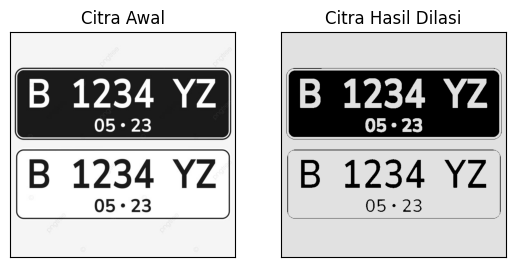

In [4]:
# Tugas 4: Dilasi dengan library
img = cv2.imread('/content/drive/MyDrive/Yuma Akhunza Kausar Putra/Plat Nomor.jpeg')
#img = cv2.imread('morp.jpg',0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3,3),np.uint16)
dilasi = cv2.dilate(thresh,kernel,iterations = 1)
print(kernel)
plt.subplot(121),plt.imshow(img),plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(dilasi),plt.title('Citra Hasil Dilasi')
plt.xticks([]), plt.yticks([])
plt.show()

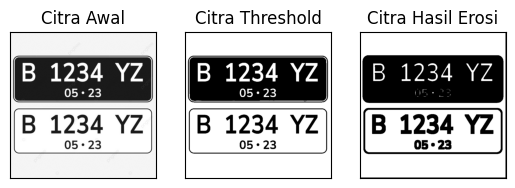

In [5]:
# Tugas 5 Erosi Tanpa Library

def erosi_citra(F, k):
    # Ukuran citra
    m, n = F.shape

    # Struktur elemen erosi (SE)
    SE = np.ones((k, k), dtype=np.uint8)
    constant = (k - 1) // 2

    # Inisialisasi citra hasil
    imgE = np.zeros((m, n), dtype=np.uint8)

    # Proses Erosi
    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            temp = F[i - constant:i + constant + 1,
                     j - constant:j + constant + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE

# Membaca citra grayscale
img_e = cv2.imread('/content/drive/MyDrive/Yuma Akhunza Kausar Putra/Plat Nomor.jpeg', 0)

# Threshold biner
ret1, thresh1 = cv2.threshold(img_e, 175, 225, cv2.THRESH_BINARY)

# Ukuran elemen struktur
k = 5

# Proses Erosi manual
imgE = erosi_citra(thresh1, k)

# Menampilkan hasil
plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(thresh1, cmap='gray')
plt.title('Citra Threshold'), plt.xticks([]), plt.yticks([])

plt.subplot(133), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi'), plt.xticks([]), plt.yticks([])

plt.show()


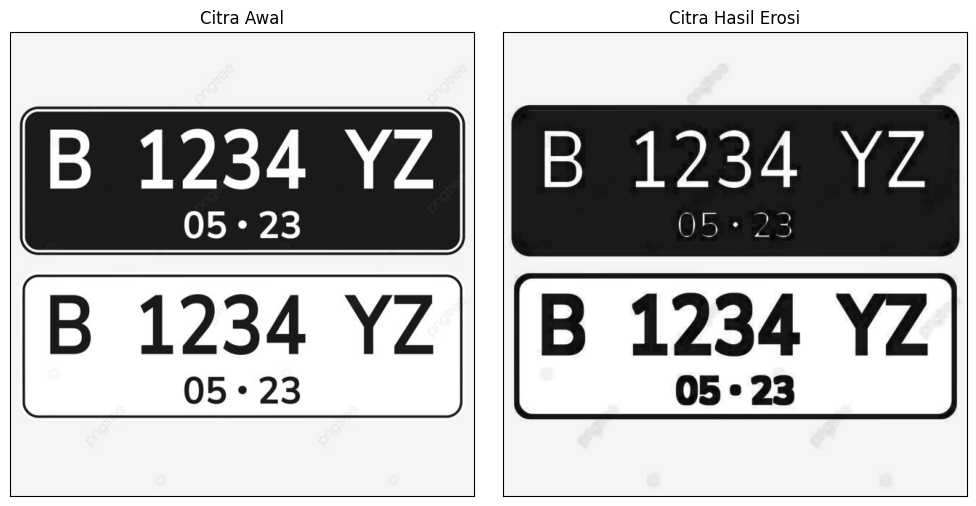

In [6]:
# Tugas 6 - Erosi Menggunakan Library OpenCV
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Membaca citra berwarna
img = cv2.imread('/content/drive/MyDrive/Yuma Akhunza Kausar Putra/Plat Nomor.jpeg')

# Membuat elemen struktur (kernel)
kernel = np.ones((5, 5), np.uint8)

# Proses erosi menggunakan fungsi bawaan OpenCV
erosion = cv2.erode(img, kernel, iterations=1)

# Menampilkan hasil
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(erosion, cv2.COLOR_BGR2RGB))
plt.title('Citra Hasil Erosi')
plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()


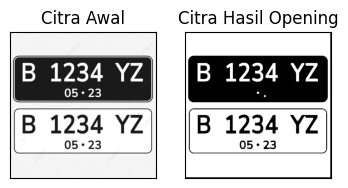

In [7]:
# Tugas 7a
img_o = cv2.imread('/content/drive/MyDrive/Yuma Akhunza Kausar Putra/Plat Nomor.jpeg', 0)

ret_o, thresh_o = cv2.threshold(img_o, 127, 225, cv2.THRESH_BINARY)
k = 7

imgO = dilasi_citra(erosi_citra(thresh_o, k), k)

plt.subplot(131), plt.imshow(img_o, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(imgO, cmap='gray')
plt.title('Citra Hasil Opening'), plt.xticks([]), plt.yticks([])

plt.show()

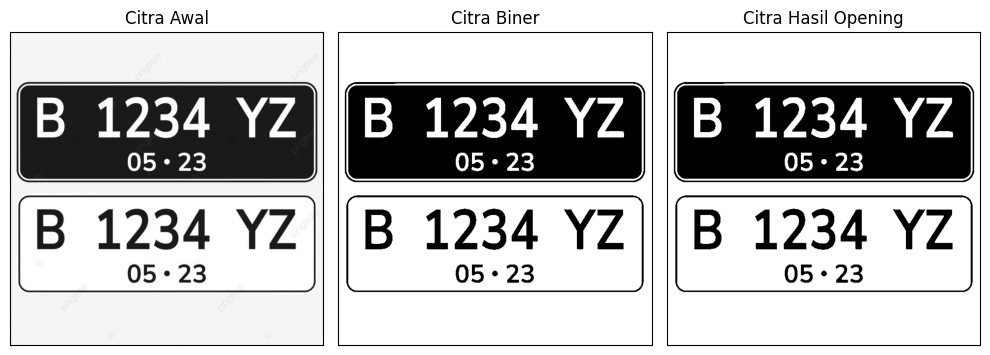

In [8]:
# Tugas 7b - Dengan Menggunakan Library
# Membaca citra grayscale
img = cv2.imread('/content/drive/MyDrive/Yuma Akhunza Kausar Putra/Plat Nomor.jpeg', 0)

# Mengubah citra menjadi biner
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)

# Membuat elemen struktur (kernel)
kernel = np.ones((3, 3), np.uint8)

# Proses Opening menggunakan fungsi morphologyEx
openn = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Menampilkan hasil
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(thresh, cmap='gray')
plt.title('Citra Biner')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(openn, cmap='gray')
plt.title('Citra Hasil Opening')
plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()


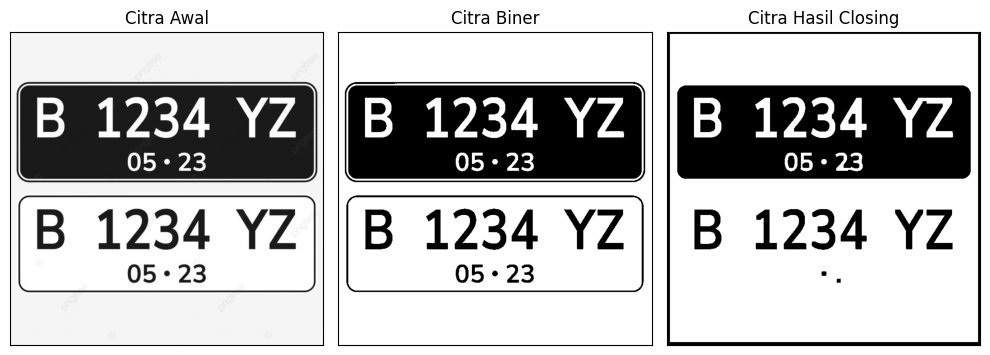

In [9]:
# Tugas 8a - Operasi Closing (Dilasi lalu Erosi) Tanpa Library

# Membaca citra grayscale
img_c = cv2.imread('/content/drive/MyDrive/Yuma Akhunza Kausar Putra/Plat Nomor.jpeg', 0)

# Mengubah citra menjadi biner
retc, threshc = cv2.threshold(img_c, 127, 225, cv2.THRESH_BINARY)

# Ukuran kernel
k = 7

# Proses Closing: Dilasi kemudian Erosi
imgC = erosi_citra(dilasi_citra(threshc, k), k)

# Menampilkan hasil
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_c, cmap='gray')
plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(threshc, cmap='gray')
plt.title('Citra Biner')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(imgC, cmap='gray')
plt.title('Citra Hasil Closing')
plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()


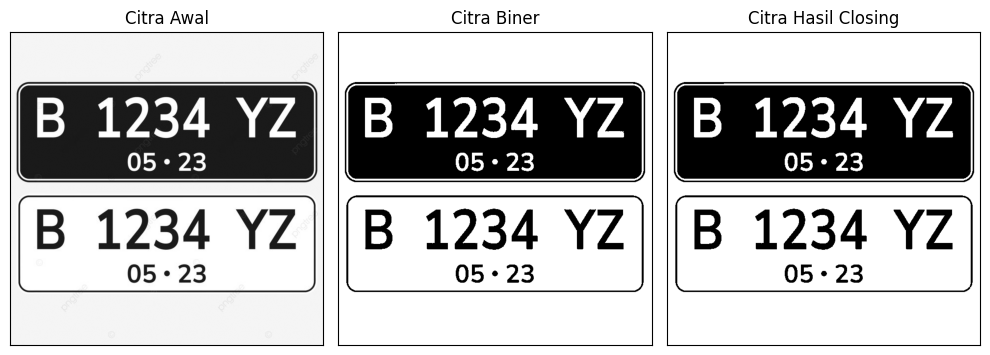

In [10]:
# Tugas 8b - Operasi Closing dengan Library Morphology
# Membaca citra grayscale
img = cv2.imread('/content/drive/MyDrive/Yuma Akhunza Kausar Putra/Plat Nomor.jpeg', 0)

# Mengubah citra menjadi biner
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)

# Membuat elemen struktur (kernel)
kernel = np.ones((3, 3), np.uint8)

# Proses Closing menggunakan morphologyEx
closs = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# Menampilkan hasil
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(thresh, cmap='gray')
plt.title('Citra Biner')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(closs, cmap='gray')
plt.title('Citra Hasil Closing')
plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()


SED = Cross 3


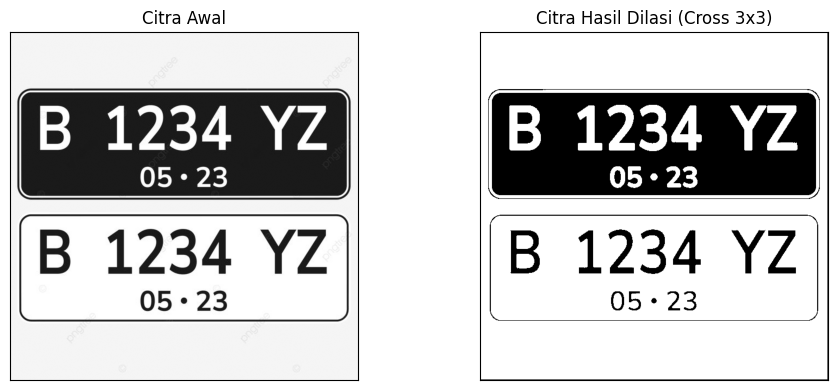

SED = Cross 5


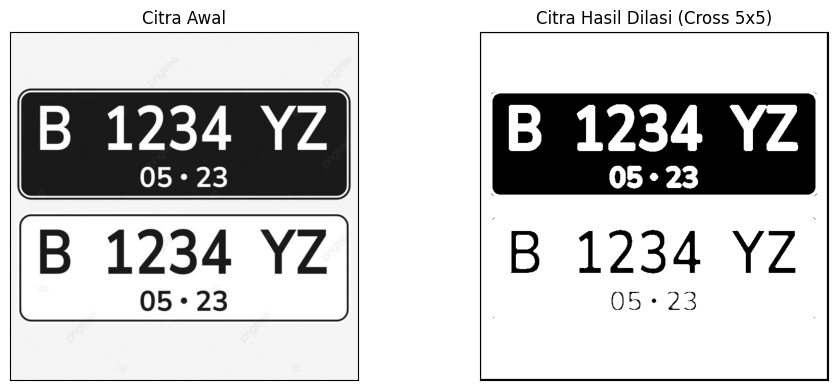

In [11]:
# Tugas 9 - Dilasi Cross Structuring Element (SED)
import cv2
import numpy as np
from matplotlib import pyplot as plt

# -------------------------------------
# Fungsi Dilasi
# -------------------------------------
def dilasi_citra(F, w, SED):
    # Ukuran citra
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Konstanta offset
    constant = (w - 1) // 2

    # Proses Dilasi
    for i in range(constant, p - constant):
        for j in range(constant, q - constant):
            temp = F[i - constant:i + constant + 1, j - constant:j + constant + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD


# -------------------------------------
# 1️⃣ Dilasi dengan SED Cross 3x3
# -------------------------------------
print('SED = Cross 3')

# Membaca citra grayscale
img_d = cv2.imread('/content/drive/MyDrive/Yuma Akhunza Kausar Putra/Plat Nomor.jpeg', 0)

# Threshold biner
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)

# Structuring Element Cross 3x3
SED3 = np.array([[0, 1, 0],
                 [1, 1, 1],
                 [0, 1, 0]], dtype=np.uint8)

w = 3
imgD3 = dilasi_citra(thresh, w, SED3)

# Menampilkan hasil
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2)
plt.imshow(imgD3, cmap='gray')
plt.title('Citra Hasil Dilasi (Cross 3x3)')
plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()


# -------------------------------------
# 2️⃣ Dilasi dengan SED Cross 5x5
# -------------------------------------
print('SED = Cross 5')

# Structuring Element Cross 5x5
SED5 = np.array([[0, 0, 1, 0, 0],
                 [0, 0, 1, 0, 0],
                 [1, 1, 1, 1, 1],
                 [0, 0, 1, 0, 0],
                 [0, 0, 1, 0, 0]], dtype=np.uint8)

w = 5
imgD5 = dilasi_citra(thresh, w, SED5)

# Menampilkan hasil
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2)
plt.imshow(imgD5, cmap='gray')
plt.title('Citra Hasil Dilasi (Cross 5x5)')
plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()


SED = Circle 3


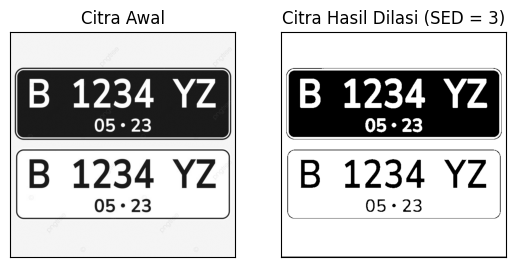

SED = Circle 5


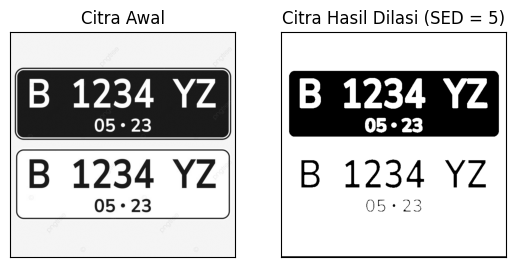

In [12]:
# 10 - Dilasi Circular SED

def dilasi_citra(F, w):
    # Ukuran citra
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Generate struktur elemen dilasi (SED)
    SED = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (w, w))
    constant1 = (w - 1) // 2

    # Proses Dilasi
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD


# ===== Dilasi dengan SED Lingkaran ukuran 3 =====
print('SED = Circle 3')
img_d = cv2.imread('/content/drive/MyDrive/Yuma Akhunza Kausar Putra/Plat Nomor.jpeg', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 3
imgD = dilasi_citra(thresh, w)

plt.subplot(121), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi (SED = 3)'), plt.xticks([]), plt.yticks([])
plt.show()


# ===== Dilasi dengan SED Lingkaran ukuran 5 =====
print('SED = Circle 5')
img_d = cv2.imread('/content/drive/MyDrive/Yuma Akhunza Kausar Putra/Plat Nomor.jpeg', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 5
imgD = dilasi_citra(thresh, w)

plt.subplot(121), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi (SED = 5)'), plt.xticks([]), plt.yticks([])
plt.show()


SE = Rectangle 3x5


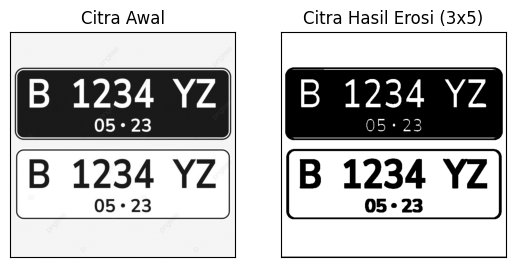

SE = Rectangle 5x7


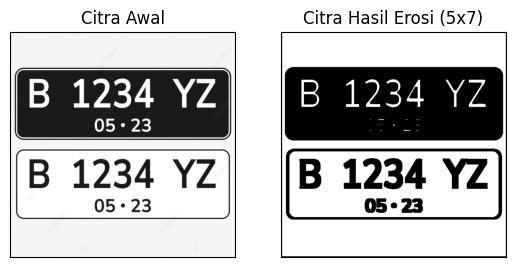

In [13]:
# 11 - Erosi Cross SE

def erosi_citra(F, p, l):
    # Ukuran citra
    m, n = F.shape

    # Generate struktur elemen erosi (SE) berbentuk persegi panjang
    SE = cv2.getStructuringElement(cv2.MORPH_RECT, (p, l))

    # Nilai konstan batas
    constant1 = (l - 1) // 2
    constant2 = (p - 1) // 2

    # Inisialisasi citra hasil erosi
    imgE = np.zeros((m, n), dtype=np.uint8)

    # Proses Erosi
    for i in range(constant1, m - constant1):
        for j in range(constant2, n - constant2):
            temp = F[i - constant1:i + constant1 + 1, j - constant2:j + constant2 + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE


# ===== Erosi dengan SE 3x5 =====
print('SE = Rectangle 3x5')
img_e = cv2.imread('/content/drive/MyDrive/Yuma Akhunza Kausar Putra/Plat Nomor.jpeg', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)

p, l = 5, 3
imgE = erosi_citra(thresh1, p, l)

plt.subplot(121), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (3x5)'), plt.xticks([]), plt.yticks([])
plt.show()


# ===== Erosi dengan SE 5x7 =====
print('SE = Rectangle 5x7')
img_e = cv2.imread('/content/drive/MyDrive/Yuma Akhunza Kausar Putra/Plat Nomor.jpeg', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)

p, l = 7, 5
imgE = erosi_citra(thresh1, p, l)

plt.subplot(121), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (5x7)'), plt.xticks([]), plt.yticks([])
plt.show()


SE = Line Vertikal 3


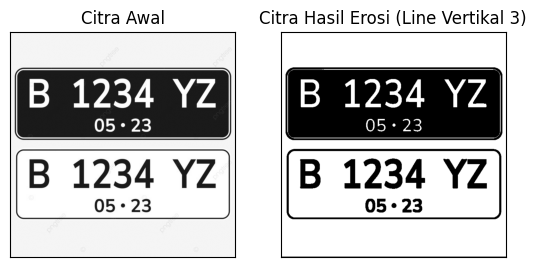

SE = Line Vertikal 5


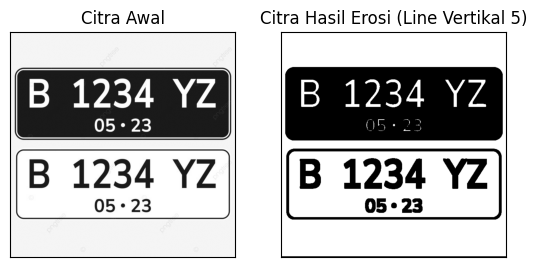

In [14]:
# 12 - Erosi Line Vertikal SE
def erosi_citra(F, k):
    # Ukuran citra
    m, n = F.shape

    # Generate struktur elemen erosi (SE) berbentuk garis vertikal
    SE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (1, k))

    # Nilai konstan batas
    constant = (k - 1) // 2

    # Inisialisasi citra hasil erosi
    imgE = np.zeros((m, n), dtype=np.uint8)

    # Proses Erosi
    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            temp = F[i - constant:i + constant + 1, j - constant:j + constant + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE


# ===== Erosi dengan SE Line Vertikal 3 =====
print('SE = Line Vertikal 3')
img_e = cv2.imread('/content/drive/MyDrive/Yuma Akhunza Kausar Putra/Plat Nomor.jpeg', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)

k = 3
imgE = erosi_citra(thresh1, k)

plt.subplot(121), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (Line Vertikal 3)'), plt.xticks([]), plt.yticks([])
plt.show()


# ===== Erosi dengan SE Line Vertikal 5 =====
print('SE = Line Vertikal 5')
img_e = cv2.imread('/content/drive/MyDrive/Yuma Akhunza Kausar Putra/Plat Nomor.jpeg', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)

k = 5
imgE = erosi_citra(thresh1, k)

plt.subplot(121), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (Line Vertikal 5)'), plt.xticks([]), plt.yticks([])
plt.show()


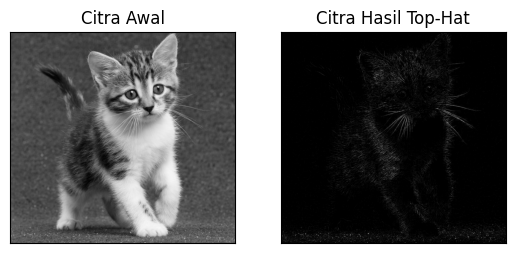

In [15]:
# 13 - Operasi Top-Hat

# Membuat kernel (struktur elemen) yang akan digunakan
filterSize = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)

# Membaca citra
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/kitten01.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Menerapkan operasi Top-Hat
tophat_img = cv2.morphologyEx(img_gray, cv2.MORPH_TOPHAT, kernel)

# Menampilkan hasil
plt.subplot(121), plt.imshow(img_gray, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(tophat_img, cmap='gray')
plt.title('Citra Hasil Top-Hat'), plt.xticks([]), plt.yticks([])

plt.show()


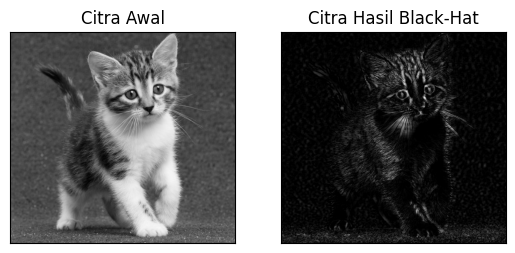

In [16]:
# 14 - Operasi Black-Hat

# Membuat kernel (struktur elemen)
filterSize = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)

# Membaca citra
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/kitten01.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Menerapkan operasi Black-Hat dengan kernel yang lebih besar (13x5)
Kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
blackhat = cv2.morphologyEx(img_gray, cv2.MORPH_BLACKHAT, Kernel)

# Menampilkan hasil
plt.subplot(121), plt.imshow(img_gray, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(blackhat, cmap='gray')
plt.title('Citra Hasil Black-Hat'), plt.xticks([]), plt.yticks([])

plt.show()


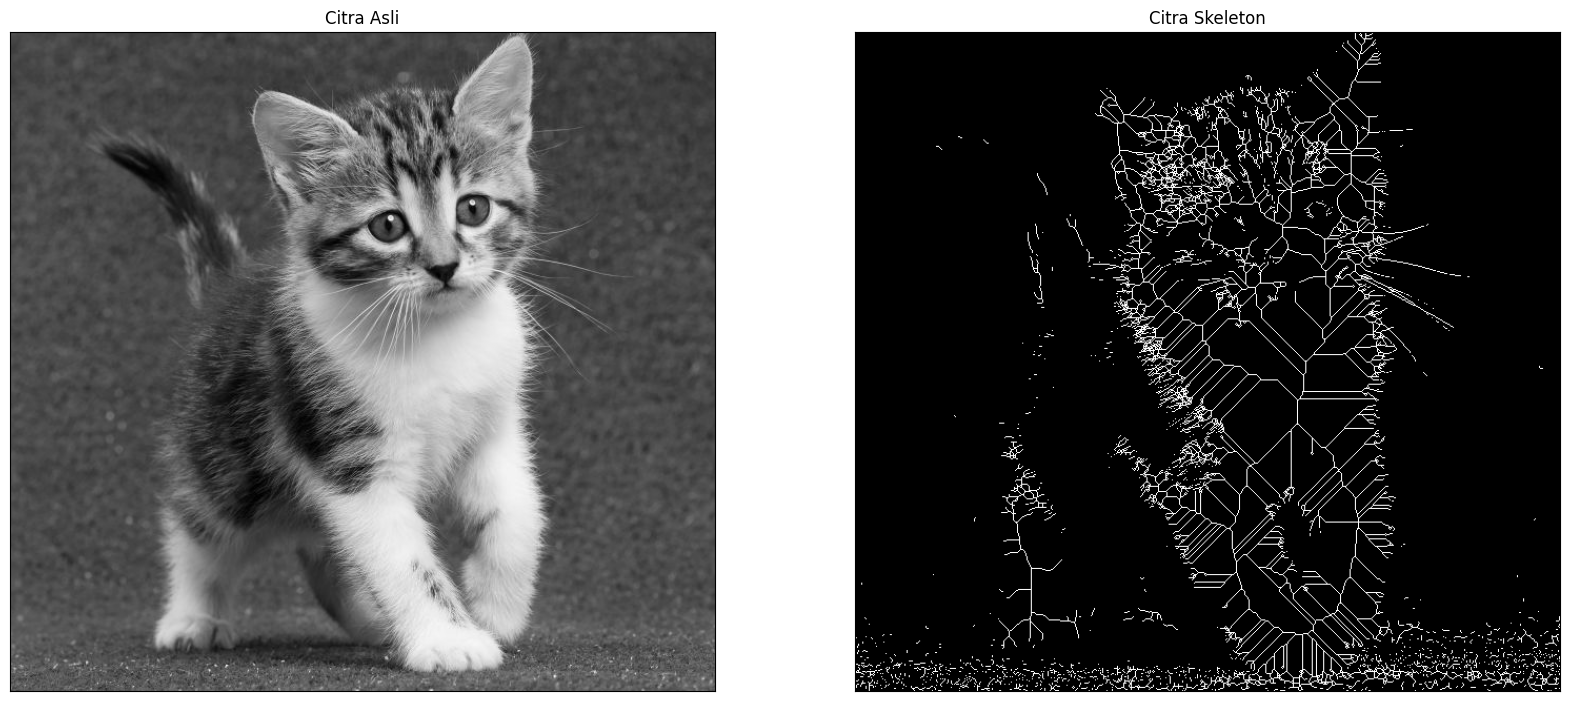

In [17]:
# 15 Skeleton
import cv2 as cv
from matplotlib import pyplot as plt
from skimage import filters
from skimage.morphology import skeletonize

# Membaca citra dalam mode grayscale
img = cv.imread('/content/drive/MyDrive/PCVK/Images/kitten01.jpg', 0)

# Mengubah citra menjadi biner menggunakan threshold Triangle
binary = img > filters.threshold_triangle(img)

# Mengonversi nilai True/False menjadi 1/0
binary_cp = binary.copy()
binary_cp[binary_cp == True] = 1
binary_cp[binary_cp == False] = 0

# Melakukan skeletonization
skeleton = skeletonize(binary_cp)

# Menampilkan hasil
plt.figure(figsize=(20, 20))
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Citra Asli'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(skeleton, cmap='gray')
plt.title('Citra Skeleton'), plt.xticks([]), plt.yticks([])

# Menyimpan hasil ke file
plt.savefig("binary_and_bin_skeleton.png")
plt.show()


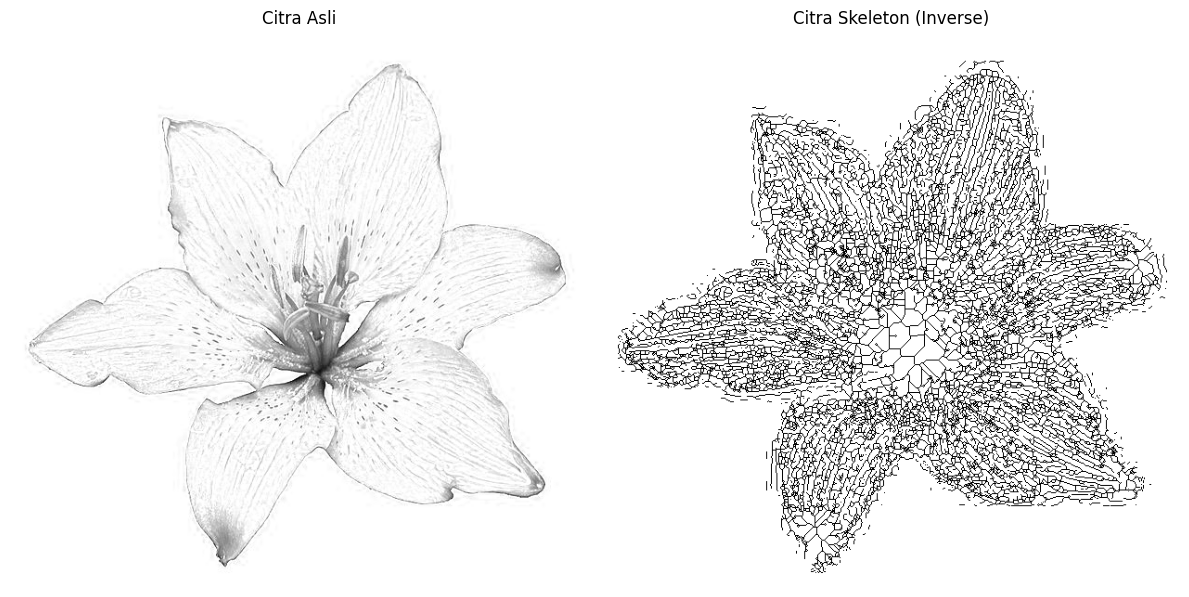

In [19]:
# 16. Skeleton Inverse

from skimage import io, filters
from skimage.morphology import skeletonize
from matplotlib import pyplot as plt

# Membaca citra (mengambil channel pertama)
img = io.imread('/content/drive/MyDrive/PCVK/Images/lily.jpg')[..., 0]

# Membuat citra biner (area hitam bernilai True)
binary = img < filters.threshold_triangle(img)

# Melakukan skeletonization
skeleton = skeletonize(binary)

# Menampilkan hasil
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Citra Asli')
ax[0].set_axis_off()

# Menggunakan colormap terbalik (gray_r)
ax[1].imshow(skeleton, cmap='gray_r')
ax[1].set_title('Citra Skeleton (Inverse)')
ax[1].set_axis_off()

plt.tight_layout()
plt.show()


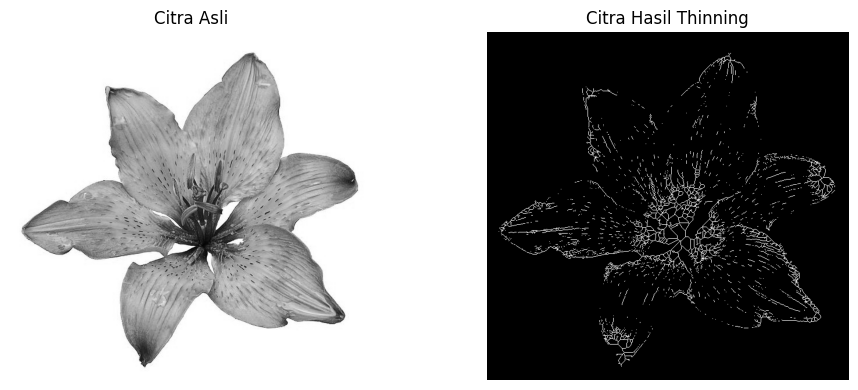

In [20]:
# 17. Thickening

from skimage import io, color, morphology, img_as_float
import matplotlib.pyplot as plt

# Membaca dan mengonversi citra menjadi grayscale float
image = img_as_float(color.rgb2gray(io.imread('/content/drive/MyDrive/PCVK/Images/lily.jpg')))

# Membuat citra biner
image_binary = image < 0.5

# Melakukan skeletonize dan thinning
out_skeletonize = morphology.skeletonize(image_binary)
out_thin = morphology.thin(image_binary)

# Menampilkan hasil
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4))

ax0.imshow(image, cmap='gray')
ax0.set_title('Citra Asli')
ax0.axis('off')

ax1.imshow(out_thin, cmap='gray')
ax1.set_title('Citra Hasil Thinning')
ax1.axis('off')

plt.tight_layout()
plt.savefig('/tmp/char_out.png')
plt.show()
